Packages loaded successfully.

Required input files found.

Treatment sites:
10

VALIDATION 1/2

Training:
P01-P08

Test:
P09

Output:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/ascm_validation/test_09
Extracting features 1080/1080

----------------------------------------------------------------------------------------------------
P09 validation | Treatment 1/10 | treatment_0001 | sentinel1

----------------------------------------------------------------------------------------------------
P09 validation | Treatment 1/10 | treatment_0001 | sentinel2

----------------------------------------------------------------------------------------------------
P09 validation | Treatment 2/10 | treatment_0002 | sentinel1

----------------------------------------------------------------------------------------------------
P09 validation | Treatment 2/10 | treatment_0002 | sentinel2

------------------------------------------------------------------------------------

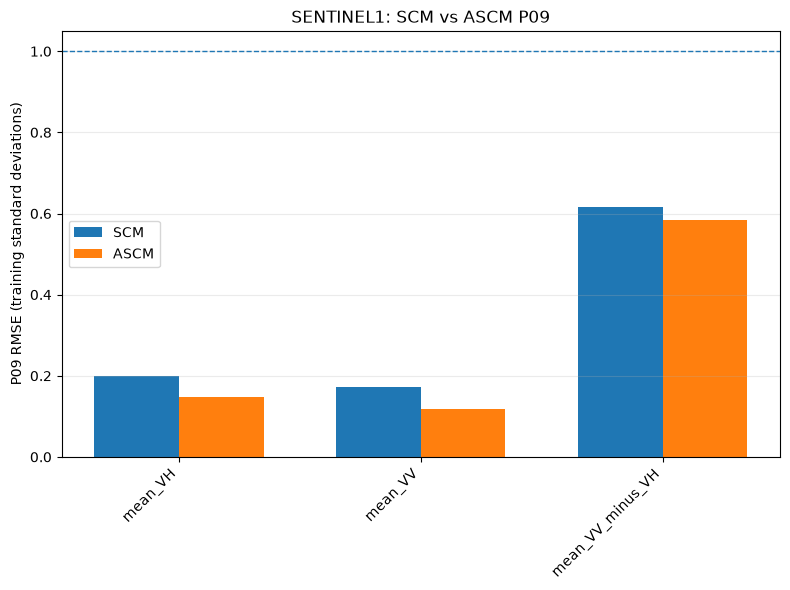

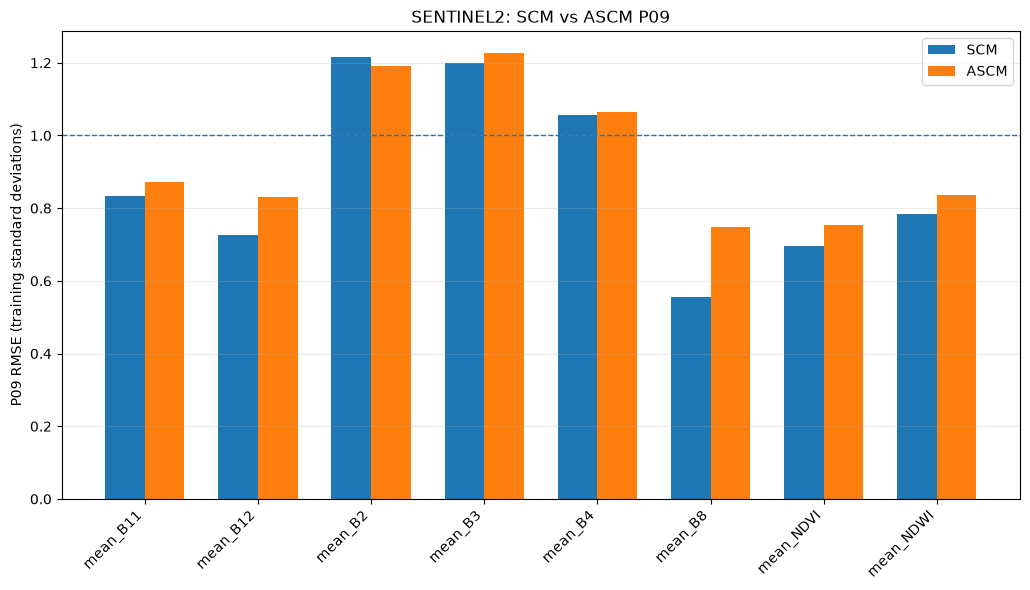

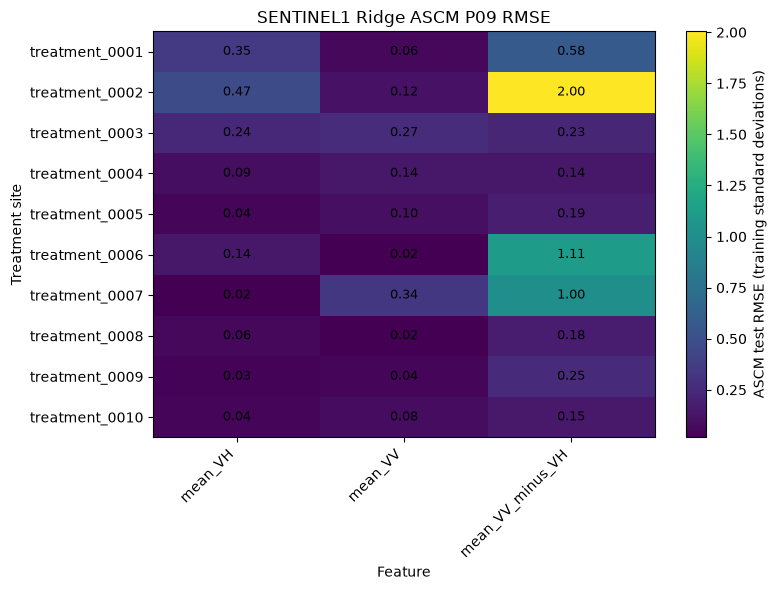

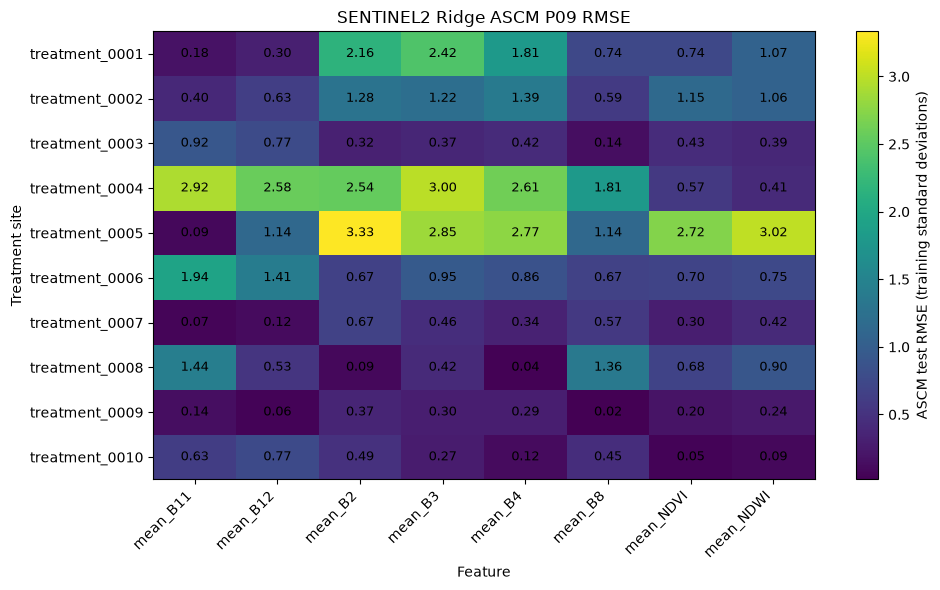

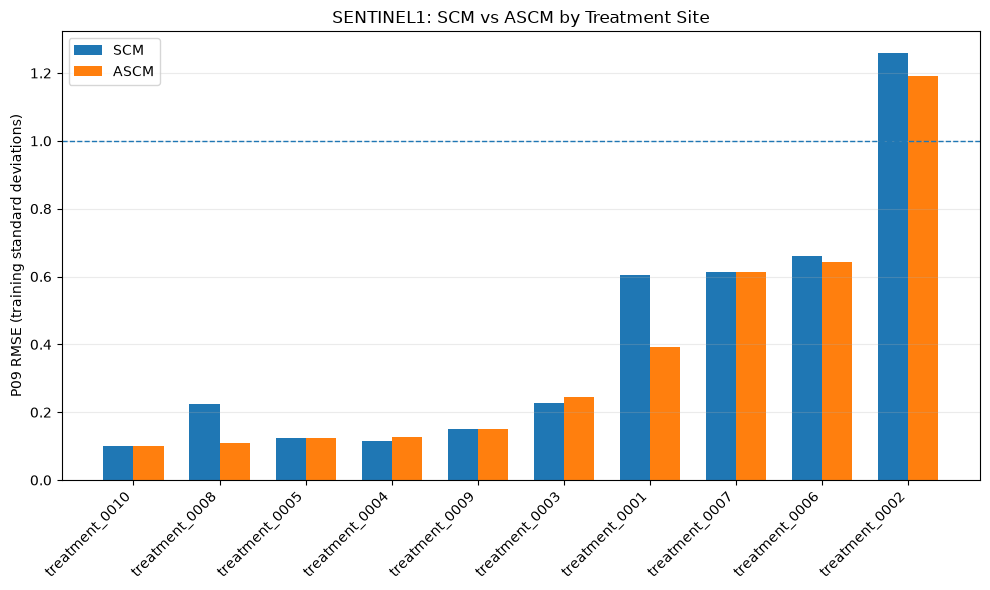

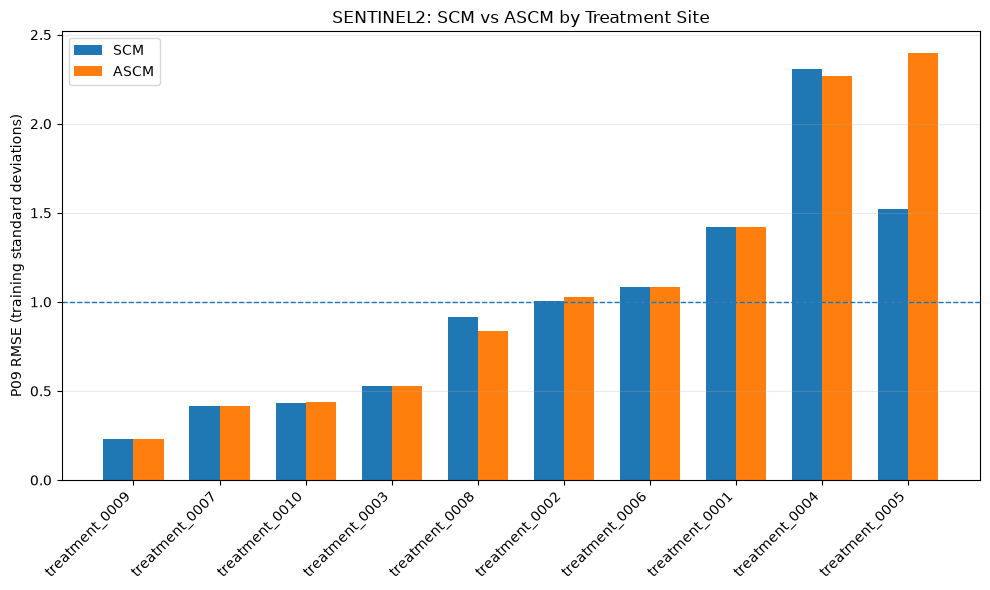

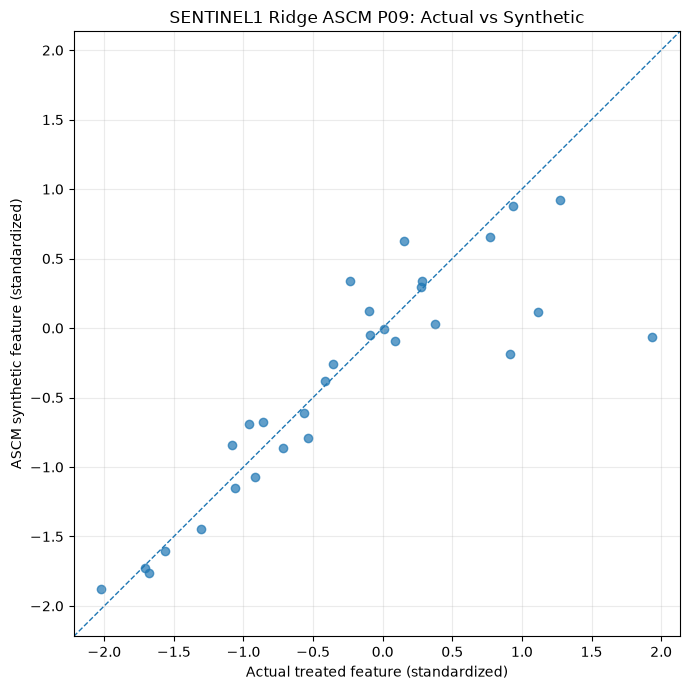

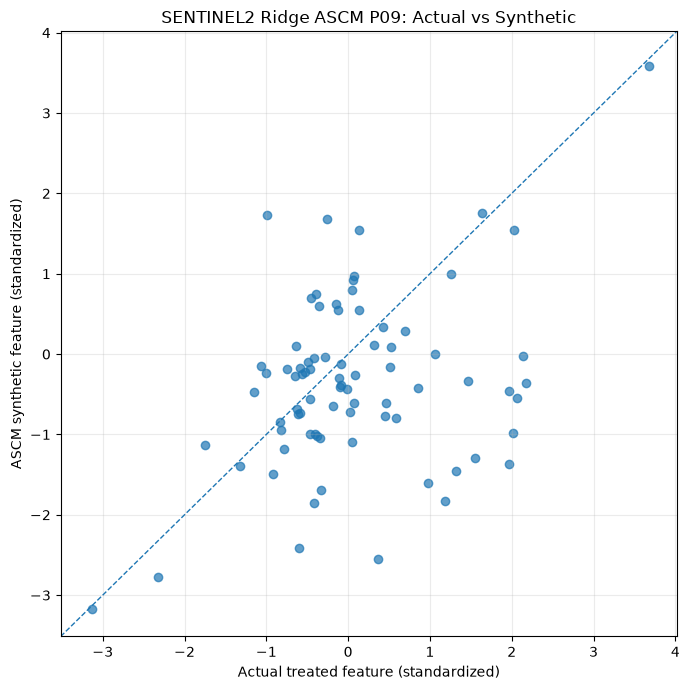


SCM vs RIDGE ASCM — P09 VALIDATION
treatment_site    sensor  scm_test_rmse  ascm_test_rmse  scm_test_mae  ascm_test_mae  number_of_test_features  ascm_rmse_improvement  ascm_improves_test training_periods test_period
treatment_0010 sentinel1       0.100956        0.100962      0.090080       0.090135                        3          -5.199499e-06               False          P01-P08         P09
treatment_0008 sentinel1       0.224882        0.108739      0.172579       0.085439                        3           1.161432e-01                True          P01-P08         P09
treatment_0005 sentinel1       0.125066        0.125066      0.110050       0.110053                        3          -2.754426e-07               False          P01-P08         P09
treatment_0004 sentinel1       0.115764        0.128149      0.114611       0.125992                        3          -1.238426e-02               False          P01-P08         P09
treatment_0009 sentinel1       0.149500        0.14950

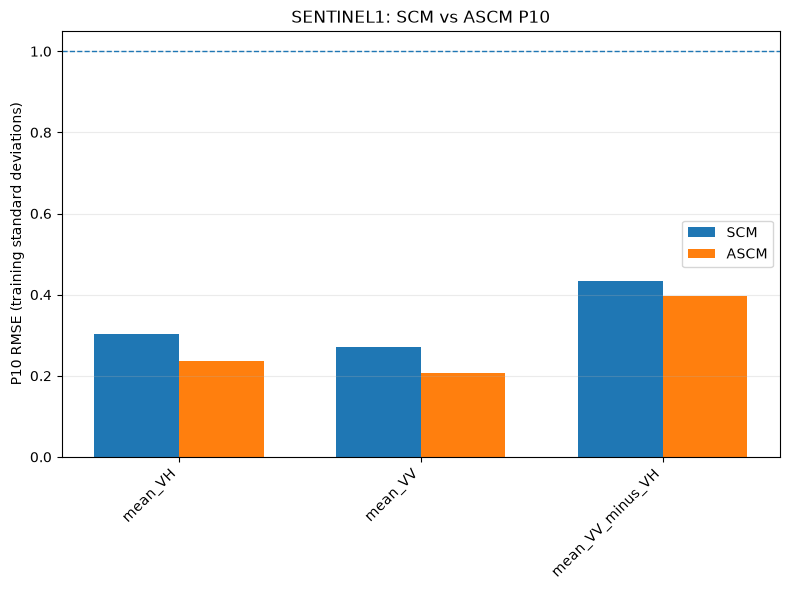

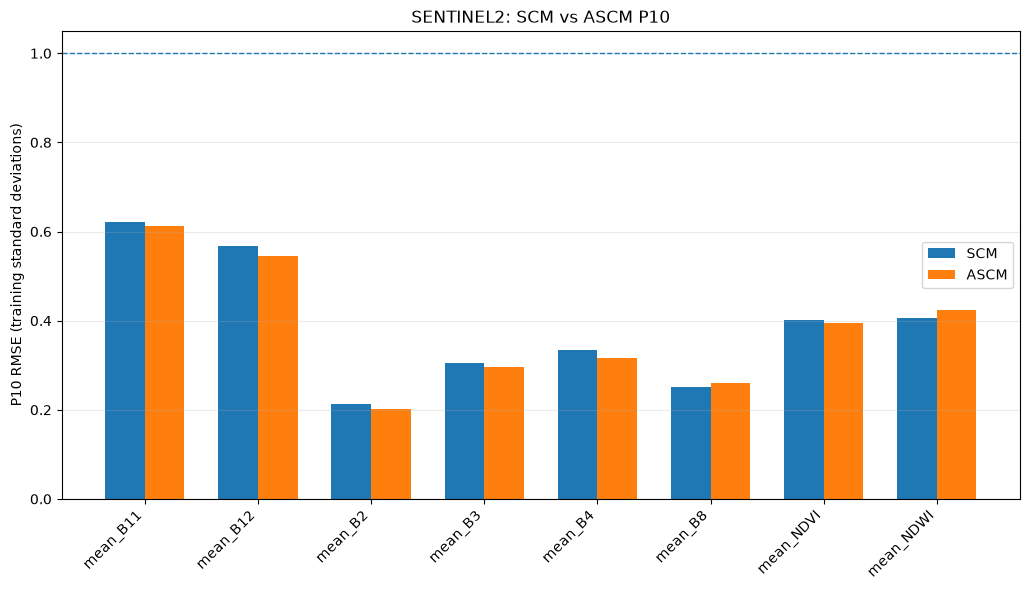

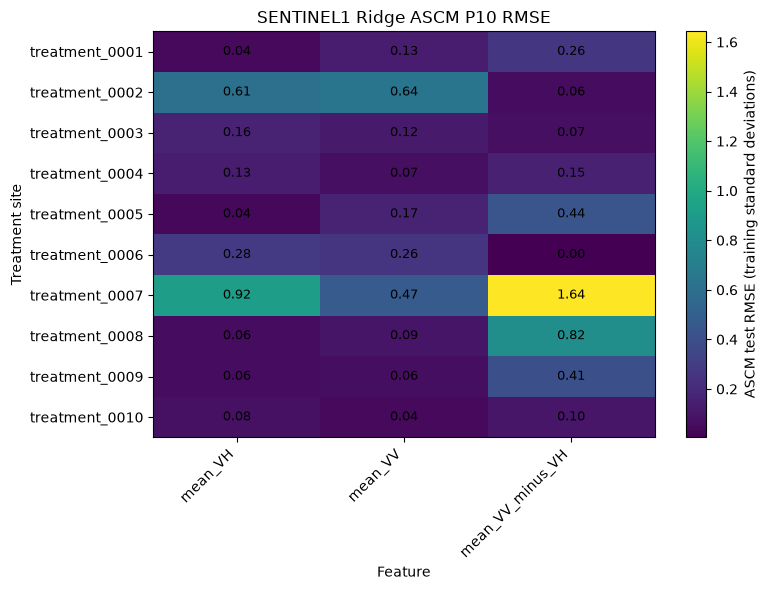

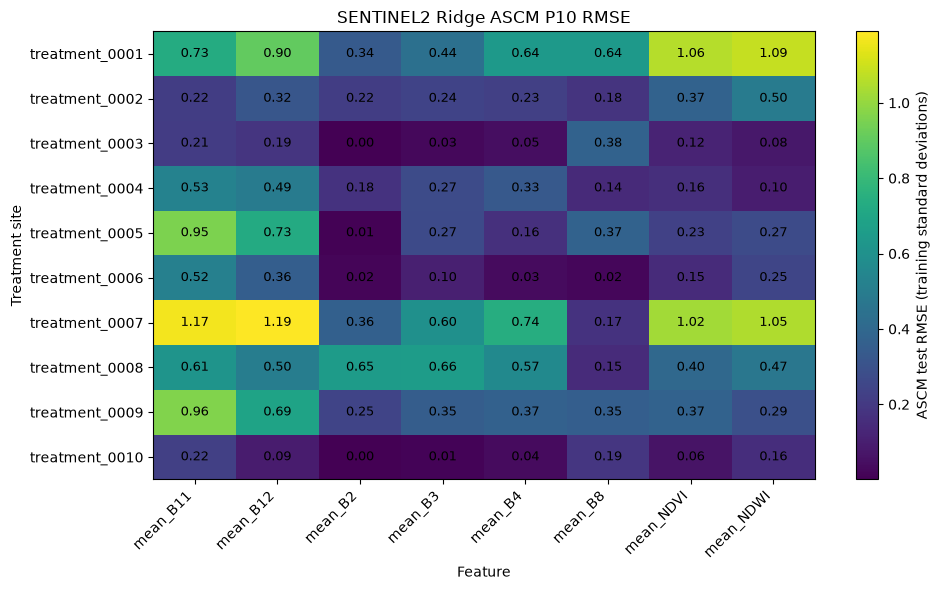

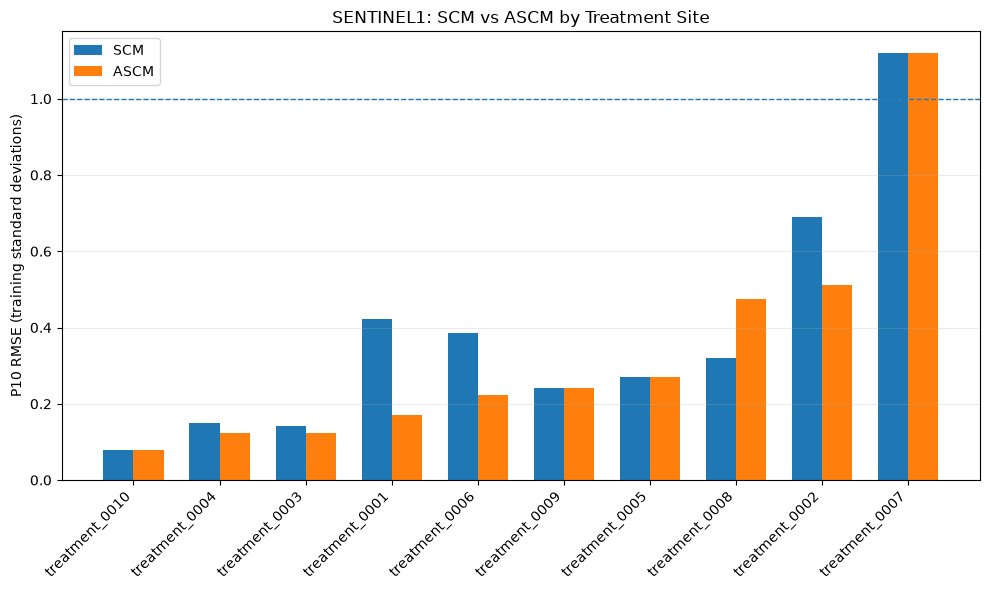

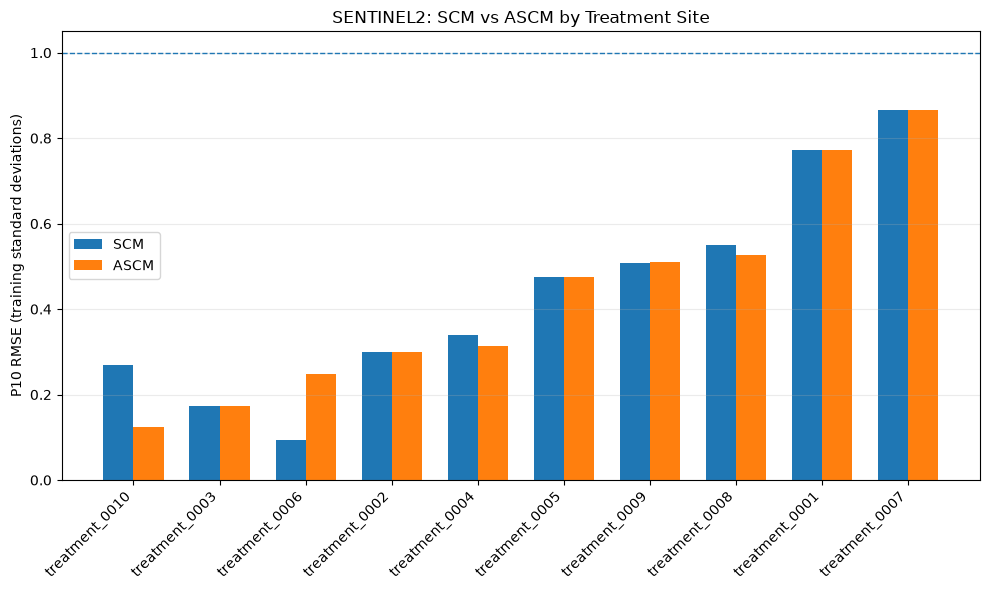

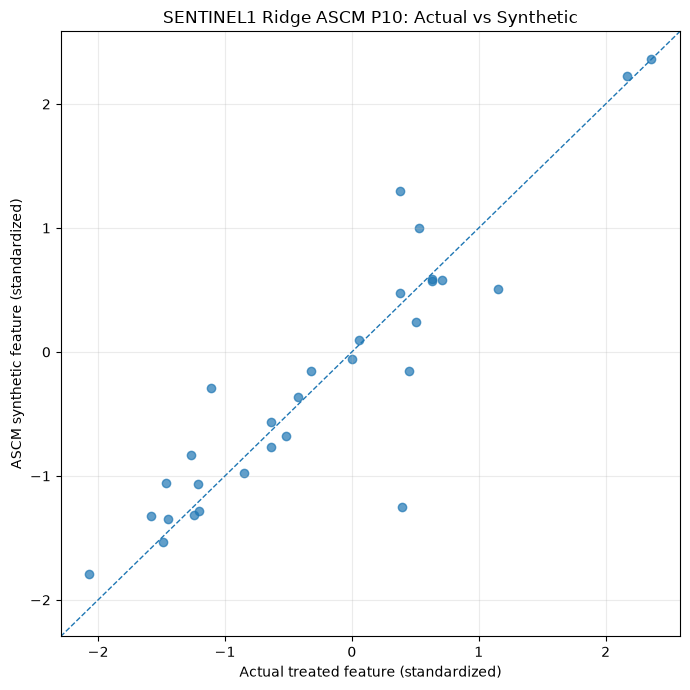

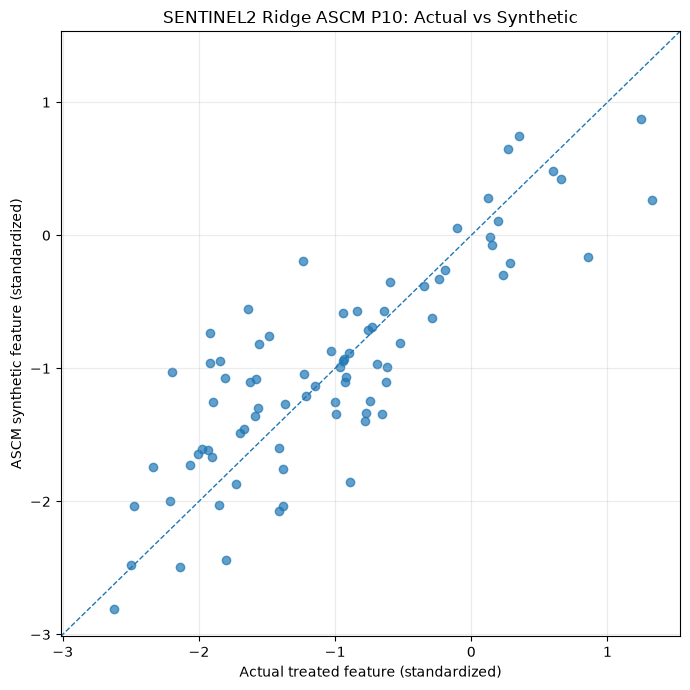


SCM vs RIDGE ASCM — P10 VALIDATION
treatment_site    sensor  scm_test_rmse  ascm_test_rmse  scm_test_mae  ascm_test_mae  number_of_test_features  ascm_rmse_improvement  ascm_improves_test training_periods test_period
treatment_0010 sentinel1       0.079635        0.079786      0.075725       0.075883                        3          -1.518480e-04               False          P01-P09         P10
treatment_0004 sentinel1       0.148986        0.122450      0.138337       0.117950                        3           2.653561e-02                True          P01-P09         P10
treatment_0003 sentinel1       0.142463        0.124008      0.135310       0.118979                        3           1.845511e-02                True          P01-P09         P10
treatment_0001 sentinel1       0.422317        0.171772      0.396723       0.146313                        3           2.505444e-01                True          P01-P09         P10
treatment_0006 sentinel1       0.386202        0.22193

In [1]:
# =============================================================================
# 17_test_ascm_single_period_validation.ipynb
#
# PURPOSE
# =============================================================================
#
# Run two single-period holdout validation exercises using:
#
#     1. Synthetic Control Method (SCM)
#     2. Ridge Augmented Synthetic Control Method (ASCM)
#
# following:
#
# Ben-Michael, Feller, and Rothstein (2021)
# "The Augmented Synthetic Control Method"
#
#
# VALIDATION DESIGN
# =============================================================================
#
# TEST 1:
#
#     P01-P08 -> TRAIN
#     P09     -> TEST
#
# Output:
#
#     test/ascm_validation/test_09/
#
#
# TEST 2:
#
#     P01-P09 -> TRAIN
#     P10     -> TEST
#
# Output:
#
#     test/ascm_validation/test_10/
#
#
# IMPORTANT
# =============================================================================
#
# For each test:
#
# The holdout period is NEVER used for:
#
#     - feature standardization
#     - SCM weight estimation
#     - ASCM lambda selection
#     - ASCM weight estimation
#
#
# Ridge lambda is selected using leave-one-training-period-out
# cross-validation within the training sample only.
#
#
# FEATURES
# =============================================================================
#
# Sentinel-1:
#
#     mean_VV
#     mean_VH
#     mean_VV_minus_VH
#
#
# Sentinel-2:
#
#     mean_B2
#     mean_B3
#     mean_B4
#     mean_B8
#     mean_B11
#     mean_B12
#     mean_NDVI
#     mean_NDWI
#
#
# SCM
# =============================================================================
#
# One weight vector is estimated for:
#
#     treatment site × sensor
#
#
# SCM:
#
#     min ||x_T - X_C w||²
#
# subject to:
#
#     w_j >= 0
#     sum(w_j) = 1
#
#
# RIDGE ASCM
# =============================================================================
#
#     min_w
#
#       1/(2 lambda) ||x_T - X_C w||²
#
#       +
#
#       1/2 ||w - w_SCM||²
#
# subject to:
#
#       sum(w_j) = 1
#
#
# ASCM allows negative weights.
#
#
# OUTPUT
# =============================================================================
#
# test/
# └── ascm_validation/
#
#     ├── test_09/
#     │   ├── 01_extracted_feature_panel.csv
#     │   ├── 02_scm_weights.csv
#     │   ├── 03_ascm_weights.csv
#     │   ├── 04_lambda_selection.csv
#     │   ├── 05_training_fit.csv
#     │   ├── 06_test_predictions.csv
#     │   ├── 07_site_validation_summary.csv
#     │   ├── 08_feature_validation_rmse.csv
#     │   ├── 09_method_comparison.csv
#     │   ├── 10_weight_diagnostics.csv
#     │   ├── 11_ascm_validation.xlsx
#     │   └── figures/
#     │
#     └── test_10/
#         └── same structure
#
# =============================================================================


# =============================================================================
# 1. PACKAGES
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio

from scipy.optimize import minimize

import matplotlib.pyplot as plt


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


print(
    "Packages loaded successfully."
)


# =============================================================================
# 2. PROJECT PATHS
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)


FINALS_DIR = (
    BASE_DIR /
    "finals"
)


BIWEEKLY_DIR = (
    FINALS_DIR /
    "biweekly_datasets"
)


BIWEEKLY_QUALITY_FILE = (
    BIWEEKLY_DIR /
    "biweekly_image_quality.csv"
)


SELECTED_SAMPLE_FILE = (
    FINALS_DIR /
    "daily_datasets" /
    "selected_site_sample.csv"
)


TEST_DIR = (
    BASE_DIR /
    "test"
)


ASCM_VALIDATION_DIR = (
    TEST_DIR /
    "ascm_validation"
)


ASCM_VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 3. VALIDATION DESIGNS
# =============================================================================

VALIDATION_DESIGNS = [

    {
        "test_period":
            9,

        "training_periods":
            list(
                range(
                    1,
                    9,
                )
            ),
    },

    {
        "test_period":
            10,

        "training_periods":
            list(
                range(
                    1,
                    10,
                )
            ),
    },

]


# =============================================================================
# 4. FEATURE DEFINITIONS
# =============================================================================

SENSOR_BANDS = {

    "sentinel1": [

        "VV",

        "VH",

        "VV_minus_VH",

    ],

    "sentinel2": [

        "B2",

        "B3",

        "B4",

        "B8",

        "B11",

        "B12",

        "NDVI",

        "NDWI",

    ],

}


SENSOR_FEATURES = {

    sensor: [

        f"mean_{band}"

        for band
        in bands

    ]

    for sensor, bands
    in SENSOR_BANDS.items()

}


# =============================================================================
# 5. LAMBDA GRID
# =============================================================================

LAMBDA_GRID = np.logspace(
    -4,
    4,
    81,
)


# =============================================================================
# 6. VERIFY INPUT FILES
# =============================================================================

required_files = [

    BIWEEKLY_QUALITY_FILE,

    SELECTED_SAMPLE_FILE,

]


missing_files = [

    file_path

    for file_path
    in required_files

    if not file_path.exists()

]


if missing_files:

    raise FileNotFoundError(
        "Required files are missing:\n\n"
        +
        "\n".join(
            str(
                file_path
            )
            for file_path
            in missing_files
        )
    )


print(
    "\nRequired input files found."
)


# =============================================================================
# 7. LOAD SELECTED SAMPLE
# =============================================================================

selected_sample = pd.read_csv(
    SELECTED_SAMPLE_FILE
)


required_sample_columns = [

    "site_id",

    "group",

    "matched_treatment_site_id",

    "control_rank",

]


missing_sample_columns = [

    column

    for column
    in required_sample_columns

    if column not in selected_sample.columns

]


if missing_sample_columns:

    raise ValueError(
        "selected_site_sample.csv is missing required columns:\n"
        +
        str(
            missing_sample_columns
        )
    )


selected_sample[
    "site_id"
] = (
    selected_sample[
        "site_id"
    ]
    .astype(str)
)


selected_sample[
    "group"
] = (
    selected_sample[
        "group"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)


selected_sample[
    "matched_treatment_site_id"
] = (
    selected_sample[
        "matched_treatment_site_id"
    ]
    .astype(str)
)


selected_sample[
    "control_rank"
] = pd.to_numeric(
    selected_sample[
        "control_rank"
    ],
    errors="coerce",
)


treatment_sites = (
    selected_sample
    .loc[
        selected_sample[
            "group"
        ]
        ==
        "treatment",
        "site_id",
    ]
    .drop_duplicates()
    .astype(str)
    .tolist()
)


print(
    "\nTreatment sites:"
)


print(
    len(
        treatment_sites
    )
)


# =============================================================================
# 8. CONVERT BEFORE/AFTER PERIOD TO GLOBAL P01-P20
# =============================================================================

def convert_to_global_period(
    period,
    period_number,
):

    period_number = int(
        period_number
    )


    if str(
        period
    ).lower() == "before":

        return period_number


    if str(
        period
    ).lower() == "after":

        return (
            period_number
            +
            10
        )


    raise ValueError(
        f"Unknown period: {period}"
    )


# =============================================================================
# 9. LOAD BIWEEKLY INVENTORY
# =============================================================================

inventory_master = pd.read_csv(
    BIWEEKLY_QUALITY_FILE
)


inventory_master[
    "site_id"
] = (
    inventory_master[
        "site_id"
    ]
    .astype(str)
)


inventory_master[
    "group"
] = (
    inventory_master[
        "group"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)


inventory_master[
    "sensor"
] = (
    inventory_master[
        "sensor"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)


inventory_master[
    "global_period"
] = [

    convert_to_global_period(
        period,
        period_number,
    )

    for period, period_number
    in zip(
        inventory_master[
            "period"
        ],
        inventory_master[
            "period_number"
        ],
    )

]


inventory_master[
    "global_period_id"
] = (

    "P"

    +

    inventory_master[
        "global_period"
    ]
    .astype(int)
    .astype(str)
    .str.zfill(
        2
    )

)


selected_ids = set(
    selected_sample[
        "site_id"
    ]
    .astype(str)
)


inventory_master = (
    inventory_master
    .loc[
        inventory_master[
            "site_id"
        ]
        .isin(
            selected_ids
        )
    ]
    .copy()
)


# =============================================================================
# 10. TIFF FEATURE EXTRACTION
# =============================================================================

def extract_band_means(
    file_path,
    band_names,
):

    if (
        pd.isna(
            file_path
        )
        or
        not Path(
            str(
                file_path
            )
        ).exists()
    ):

        return {

            f"mean_{band}":
                np.nan

            for band
            in band_names

        }


    file_path = Path(
        str(
            file_path
        )
    )


    with rasterio.open(
        file_path
    ) as src:

        data = (
            src
            .read(
                masked=True
            )
            .astype(
                "float64"
            )
            .filled(
                np.nan
            )
        )


    if (
        data.shape[
            0
        ]
        !=
        len(
            band_names
        )
    ):

        raise ValueError(
            f"{file_path}: expected "
            f"{len(band_names)} bands but "
            f"found {data.shape[0]}."
        )


    output = {}


    for band_index, band_name in enumerate(
        band_names
    ):

        values = (
            data[
                band_index
            ]
        )


        finite = np.isfinite(
            values
        )


        output[
            f"mean_{band_name}"
        ] = (
            float(
                np.mean(
                    values[
                        finite
                    ]
                )
            )
            if finite.any()
            else np.nan
        )


    return output


# =============================================================================
# 11. DONOR HELPER
# =============================================================================

def get_donor_ids(
    treatment_site,
):

    return (
        selected_sample
        .loc[
            (
                selected_sample[
                    "group"
                ]
                ==
                "counterfactual"
            )
            &
            (
                selected_sample[
                    "matched_treatment_site_id"
                ]
                ==
                str(
                    treatment_site
                )
            )
        ]
        .sort_values(
            "control_rank"
        )
        [
            "site_id"
        ]
        .astype(str)
        .tolist()
    )


# =============================================================================
# 12. FEATURE SCALER
#
# Uses only training-period donor observations.
# =============================================================================

def calculate_training_scaler(
    donors,
    features,
    training_periods,
):

    train = (
        donors
        .loc[
            donors[
                "global_period"
            ]
            .isin(
                training_periods
            )
        ]
        .copy()
    )


    means = {}

    stds = {}


    for feature in features:

        values = pd.to_numeric(
            train[
                feature
            ],
            errors="coerce",
        )


        mean_value = float(
            values.mean()
        )


        sd_value = float(
            values.std(
                ddof=0
            )
        )


        if (
            not np.isfinite(
                sd_value
            )
            or
            sd_value < 1e-8
        ):

            sd_value = 1.0


        means[
            feature
        ] = mean_value


        stds[
            feature
        ] = sd_value


    return (
        means,
        stds,
    )


def standardize_frame(
    dataframe,
    features,
    means,
    stds,
):

    dataframe = (
        dataframe.copy()
    )


    for feature in features:

        dataframe[
            feature
        ] = (

            pd.to_numeric(
                dataframe[
                    feature
                ],
                errors="coerce",
            )

            -

            means[
                feature
            ]

        ) / stds[
            feature
        ]


    return dataframe


# =============================================================================
# 13. DESIGN MATRIX CREATION
# =============================================================================

def create_design_matrices(
    treatment,
    donors,
    donor_ids,
    features,
    periods,
):

    treated_values = []

    donor_values = []

    labels = []


    for period_number in periods:

        treated_period = (
            treatment
            .loc[
                treatment[
                    "global_period"
                ]
                ==
                period_number
            ]
        )


        if treated_period.empty:

            for feature in features:

                treated_values.append(
                    np.nan
                )


                donor_values.append(
                    [
                        np.nan
                        for _
                        in donor_ids
                    ]
                )


                labels.append(
                    (
                        period_number,
                        feature,
                    )
                )


            continue


        for feature in features:

            treated_value = (
                treated_period[
                    feature
                ]
                .iloc[
                    0
                ]
            )


            current_donors = []


            for donor_id in donor_ids:

                donor_period = (
                    donors
                    .loc[
                        (
                            donors[
                                "site_id"
                            ]
                            ==
                            donor_id
                        )
                        &
                        (
                            donors[
                                "global_period"
                            ]
                            ==
                            period_number
                        )
                    ]
                )


                if donor_period.empty:

                    donor_value = np.nan


                else:

                    donor_value = (
                        donor_period[
                            feature
                        ]
                        .iloc[
                            0
                        ]
                    )


                current_donors.append(
                    donor_value
                )


            treated_values.append(
                treated_value
            )


            donor_values.append(
                current_donors
            )


            labels.append(
                (
                    period_number,
                    feature,
                )
            )


    return (

        np.asarray(
            treated_values,
            dtype=float,
        ),

        np.asarray(
            donor_values,
            dtype=float,
        ),

        labels,

    )


# =============================================================================
# 14. REMOVE INCOMPLETE TRAINING ROWS
# =============================================================================

def remove_missing_rows(
    x_treated,
    X_donors,
    labels,
):

    valid = (

        np.isfinite(
            x_treated
        )

        &

        np.isfinite(
            X_donors
        )
        .all(
            axis=1
        )

    )


    return (

        x_treated[
            valid
        ],

        X_donors[
            valid,
            :
        ],

        [

            label

            for label, keep
            in zip(
                labels,
                valid,
            )

            if keep

        ],

    )


# =============================================================================
# 15. STANDARD SCM
# =============================================================================

def fit_scm(
    x_treated,
    X_donors,
):

    number_of_donors = (
        X_donors.shape[
            1
        ]
    )


    if (
        len(
            x_treated
        )
        ==
        0
    ):

        raise ValueError(
            "No training observations."
        )


    initial_weights = np.repeat(
        1.0
        /
        number_of_donors,
        number_of_donors,
    )


    def objective(
        weights,
    ):

        residual = (

            x_treated

            -

            X_donors
            @
            weights

        )


        return float(
            np.mean(
                residual
                **
                2
            )
        )


    constraints = [

        {

            "type":
                "eq",

            "fun":
                lambda weights:
                    np.sum(
                        weights
                    )
                    -
                    1.0,

        }

    ]


    bounds = [

        (
            0.0,
            1.0,
        )

        for _
        in range(
            number_of_donors
        )

    ]


    result = minimize(

        objective,

        initial_weights,

        method="SLSQP",

        bounds=
            bounds,

        constraints=
            constraints,

        options={

            "maxiter":
                5000,

            "ftol":
                1e-12,

        },

    )


    if not result.success:

        raise RuntimeError(
            "SCM optimization failed: "
            +
            result.message
        )


    return result.x


# =============================================================================
# 16. RIDGE ASCM
# =============================================================================

def fit_ridge_ascm(
    x_treated,
    X_donors,
    scm_weights,
    lambda_value,
):

    number_of_donors = (
        X_donors.shape[
            1
        ]
    )


    H = (

        np.eye(
            number_of_donors
        )

        +

        (
            X_donors.T
            @
            X_donors
        )
        /
        lambda_value

    )


    b = (

        scm_weights

        +

        (
            X_donors.T
            @
            x_treated
        )
        /
        lambda_value

    )


    ones = np.ones(
        (
            number_of_donors,
            1,
        )
    )


    KKT = np.block(

        [

            [
                H,
                ones,
            ],

            [
                ones.T,
                np.zeros(
                    (
                        1,
                        1,
                    )
                ),
            ],

        ]

    )


    rhs = np.concatenate(
        [

            b,

            np.asarray(
                [
                    1.0
                ]
            ),

        ]
    )


    solution = np.linalg.solve(
        KKT,
        rhs,
    )


    return (
        solution[
            :
            number_of_donors
        ]
    )


# =============================================================================
# 17. LAMBDA CROSS-VALIDATION
# =============================================================================

def cross_validate_lambda(
    treatment,
    donors,
    donor_ids,
    features,
    training_periods,
):

    cv_records = []


    for lambda_value in LAMBDA_GRID:

        squared_errors = []

        number_predictions = 0


        for holdout_period in training_periods:

            fit_periods = [

                period

                for period
                in training_periods

                if period
                !=
                holdout_period

            ]


            (
                x_fit,
                X_fit,
                labels_fit,
            ) = (
                create_design_matrices(

                    treatment=
                        treatment,

                    donors=
                        donors,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    periods=
                        fit_periods,

                )
            )


            (
                x_fit,
                X_fit,
                labels_fit,
            ) = (
                remove_missing_rows(
                    x_fit,
                    X_fit,
                    labels_fit,
                )
            )


            if len(
                x_fit
            ) == 0:

                continue


            try:

                scm_weights = (
                    fit_scm(
                        x_fit,
                        X_fit,
                    )
                )


                ascm_weights = (
                    fit_ridge_ascm(

                        x_treated=
                            x_fit,

                        X_donors=
                            X_fit,

                        scm_weights=
                            scm_weights,

                        lambda_value=
                            lambda_value,

                    )
                )


            except Exception:

                continue


            (
                x_test,
                X_test,
                labels_test,
            ) = (
                create_design_matrices(

                    treatment=
                        treatment,

                    donors=
                        donors,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    periods=[
                        holdout_period
                    ],

                )
            )


            (
                x_test,
                X_test,
                labels_test,
            ) = (
                remove_missing_rows(
                    x_test,
                    X_test,
                    labels_test,
                )
            )


            if len(
                x_test
            ) == 0:

                continue


            predictions = (
                X_test
                @
                ascm_weights
            )


            errors = (
                x_test
                -
                predictions
            )


            squared_errors.extend(
                (
                    errors
                    **
                    2
                )
                .tolist()
            )


            number_predictions += (
                len(
                    errors
                )
            )


        cv_mse = (
            float(
                np.mean(
                    squared_errors
                )
            )
            if squared_errors
            else np.nan
        )


        cv_records.append(
            {

                "lambda":
                    float(
                        lambda_value
                    ),

                "cv_mse":
                    cv_mse,

                "cv_rmse":
                    (
                        float(
                            np.sqrt(
                                cv_mse
                            )
                        )
                        if np.isfinite(
                            cv_mse
                        )
                        else np.nan
                    ),

                "number_of_predictions":
                    number_predictions,

            }
        )


    cv_table = pd.DataFrame(
        cv_records
    )


    valid = (
        cv_table
        .dropna(
            subset=[
                "cv_mse"
            ]
        )
        .copy()
    )


    if valid.empty:

        raise RuntimeError(
            "No valid lambda cross-validation result."
        )


    best_row = (
        valid
        .sort_values(
            "cv_mse"
        )
        .iloc[
            0
        ]
    )


    return (

        float(
            best_row[
                "lambda"
            ]
        ),

        cv_table,

    )


# =============================================================================
# 18. RUN BOTH VALIDATION DESIGNS
# =============================================================================

for design_number, design in enumerate(
    VALIDATION_DESIGNS,
    start=1,
):

    TEST_PERIOD = int(
        design[
            "test_period"
        ]
    )


    TRAIN_PERIODS = (
        design[
            "training_periods"
        ]
    )


    TRAIN_LABEL = (
        f"P01-P{TRAIN_PERIODS[-1]:02d}"
    )


    TEST_LABEL = (
        f"P{TEST_PERIOD:02d}"
    )


    PERIODS_TO_USE = (
        TRAIN_PERIODS
        +
        [
            TEST_PERIOD
        ]
    )


    OUTPUT_DIR = (
        ASCM_VALIDATION_DIR /
        f"test_{TEST_PERIOD:02d}"
    )


    FIGURE_DIR = (
        OUTPUT_DIR /
        "figures"
    )


    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


    FIGURE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


    # =========================================================================
    # Output files
    # =========================================================================

    FEATURE_PANEL_FILE = (
        OUTPUT_DIR /
        "01_extracted_feature_panel.csv"
    )


    SCM_WEIGHT_FILE = (
        OUTPUT_DIR /
        "02_scm_weights.csv"
    )


    ASCM_WEIGHT_FILE = (
        OUTPUT_DIR /
        "03_ascm_weights.csv"
    )


    LAMBDA_FILE = (
        OUTPUT_DIR /
        "04_lambda_selection.csv"
    )


    TRAINING_FIT_FILE = (
        OUTPUT_DIR /
        "05_training_fit.csv"
    )


    TEST_PREDICTION_FILE = (
        OUTPUT_DIR /
        "06_test_predictions.csv"
    )


    SITE_SUMMARY_FILE = (
        OUTPUT_DIR /
        "07_site_validation_summary.csv"
    )


    FEATURE_RMSE_FILE = (
        OUTPUT_DIR /
        "08_feature_validation_rmse.csv"
    )


    METHOD_COMPARISON_FILE = (
        OUTPUT_DIR /
        "09_method_comparison.csv"
    )


    WEIGHT_DIAGNOSTIC_FILE = (
        OUTPUT_DIR /
        "10_weight_diagnostics.csv"
    )


    EXCEL_FILE = (
        OUTPUT_DIR /
        "11_ascm_validation.xlsx"
    )


    print(
        "\n"
        + "=" * 120
    )


    print(
        f"VALIDATION {design_number}/2"
    )


    print(
        "=" * 120
    )


    print(
        "\nTraining:"
    )


    print(
        TRAIN_LABEL
    )


    print(
        "\nTest:"
    )


    print(
        TEST_LABEL
    )


    print(
        "\nOutput:"
    )


    print(
        OUTPUT_DIR
    )


    # =========================================================================
    # Restrict inventory to this validation design
    # =========================================================================

    inventory = (
        inventory_master
        .loc[
            inventory_master[
                "global_period"
            ]
            .isin(
                PERIODS_TO_USE
            )
        ]
        .copy()
    )


    # =========================================================================
    # Extract feature panel
    # =========================================================================

    feature_records = []


    total_rows = len(
        inventory
    )


    for row_number, (_, row) in enumerate(
        inventory.iterrows(),
        start=1,
    ):

        sensor = str(
            row[
                "sensor"
            ]
        )


        if sensor not in SENSOR_BANDS:

            continue


        print(
            f"\rExtracting features "
            f"{row_number}/{total_rows}",
            end="",
        )


        feature_values = (
            extract_band_means(

                file_path=
                    row.get(
                        "output_file"
                    ),

                band_names=
                    SENSOR_BANDS[
                        sensor
                    ],

            )
        )


        record = {

            "site_id":
                str(
                    row[
                        "site_id"
                    ]
                ),

            "group":
                str(
                    row[
                        "group"
                    ]
                ),

            "sensor":
                sensor,

            "period":
                row.get(
                    "period"
                ),

            "period_number":
                row.get(
                    "period_number"
                ),

            "global_period":
                int(
                    row[
                        "global_period"
                    ]
                ),

            "global_period_id":
                row[
                    "global_period_id"
                ],

            "valid_pixel_fraction":
                row.get(
                    "valid_pixel_fraction",
                    np.nan,
                ),

            "valid_pixel_percentage":
                row.get(
                    "valid_pixel_percentage",
                    np.nan,
                ),

            "output_file":
                row.get(
                    "output_file"
                ),

        }


        record.update(
            feature_values
        )


        feature_records.append(
            record
        )


    print()


    feature_panel = pd.DataFrame(
        feature_records
    )


    metadata = (
        selected_sample[
            [
                "site_id",
                "group",
                "matched_treatment_site_id",
                "control_rank",
            ]
        ]
        .drop_duplicates()
    )


    feature_panel = (
        feature_panel
        .merge(

            metadata,

            on=[
                "site_id",
                "group",
            ],

            how="left",

        )
    )


    feature_panel.to_csv(
        FEATURE_PANEL_FILE,
        index=False,
    )


    # =========================================================================
    # Result containers
    # =========================================================================

    scm_weight_records = []

    ascm_weight_records = []

    lambda_records = []

    training_records = []

    test_records = []

    diagnostic_records = []


    # =========================================================================
    # Treatment × sensor loop
    # =========================================================================

    for treatment_number, treatment_site in enumerate(
        treatment_sites,
        start=1,
    ):

        for sensor in [

            "sentinel1",

            "sentinel2",

        ]:

            print(
                "\n"
                + "-" * 100
            )


            print(
                f"{TEST_LABEL} validation | "
                f"Treatment {treatment_number}/"
                f"{len(treatment_sites)} | "
                f"{treatment_site} | "
                f"{sensor}"
            )


            donor_ids = (
                get_donor_ids(
                    treatment_site
                )
            )


            if len(
                donor_ids
            ) == 0:

                print(
                    "No donors."
                )

                continue


            features = (
                SENSOR_FEATURES[
                    sensor
                ]
            )


            treatment = (
                feature_panel
                .loc[
                    (
                        feature_panel[
                            "site_id"
                        ]
                        ==
                        str(
                            treatment_site
                        )
                    )
                    &
                    (
                        feature_panel[
                            "sensor"
                        ]
                        ==
                        sensor
                    )
                ]
                .copy()
            )


            donors = (
                feature_panel
                .loc[
                    (
                        feature_panel[
                            "site_id"
                        ]
                        .isin(
                            donor_ids
                        )
                    )
                    &
                    (
                        feature_panel[
                            "sensor"
                        ]
                        ==
                        sensor
                    )
                ]
                .copy()
            )


            if treatment.empty:

                print(
                    "Treatment image data missing."
                )

                continue


            # =================================================================
            # Standardization using training-period donors only
            # =================================================================

            means, stds = (
                calculate_training_scaler(

                    donors=
                        donors,

                    features=
                        features,

                    training_periods=
                        TRAIN_PERIODS,

                )
            )


            treatment_z = (
                standardize_frame(
                    treatment,
                    features,
                    means,
                    stds,
                )
            )


            donors_z = (
                standardize_frame(
                    donors,
                    features,
                    means,
                    stds,
                )
            )


            # =================================================================
            # Training matrices
            # =================================================================

            (
                x_train,
                X_train,
                train_labels,
            ) = (
                create_design_matrices(

                    treatment=
                        treatment_z,

                    donors=
                        donors_z,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    periods=
                        TRAIN_PERIODS,

                )
            )


            (
                x_train,
                X_train,
                train_labels,
            ) = (
                remove_missing_rows(
                    x_train,
                    X_train,
                    train_labels,
                )
            )


            if len(
                x_train
            ) == 0:

                print(
                    "No complete training rows."
                )

                continue


            # =================================================================
            # SCM
            # =================================================================

            try:

                scm_weights = (
                    fit_scm(
                        x_train,
                        X_train,
                    )
                )


            except Exception as error:

                print(
                    "SCM failed:",
                    error
                )

                continue


            scm_train_pred = (
                X_train
                @
                scm_weights
            )


            scm_train_error = (
                x_train
                -
                scm_train_pred
            )


            scm_train_rmse = float(
                np.sqrt(
                    np.mean(
                        scm_train_error
                        **
                        2
                    )
                )
            )


            # =================================================================
            # Lambda selection
            # =================================================================

            try:

                best_lambda, cv_table = (
                    cross_validate_lambda(

                        treatment=
                            treatment_z,

                        donors=
                            donors_z,

                        donor_ids=
                            donor_ids,

                        features=
                            features,

                        training_periods=
                            TRAIN_PERIODS,

                    )
                )


            except Exception as error:

                print(
                    "Lambda CV failed:",
                    error
                )

                continue


            cv_table[
                "treatment_site"
            ] = treatment_site


            cv_table[
                "sensor"
            ] = sensor


            cv_table[
                "training_periods"
            ] = TRAIN_LABEL


            cv_table[
                "test_period"
            ] = TEST_LABEL


            lambda_records.extend(
                cv_table.to_dict(
                    "records"
                )
            )


            # =================================================================
            # ASCM
            # =================================================================

            try:

                ascm_weights = (
                    fit_ridge_ascm(

                        x_treated=
                            x_train,

                        X_donors=
                            X_train,

                        scm_weights=
                            scm_weights,

                        lambda_value=
                            best_lambda,

                    )
                )


            except Exception as error:

                print(
                    "ASCM failed:",
                    error
                )

                continue


            ascm_train_pred = (
                X_train
                @
                ascm_weights
            )


            ascm_train_error = (
                x_train
                -
                ascm_train_pred
            )


            ascm_train_rmse = float(
                np.sqrt(
                    np.mean(
                        ascm_train_error
                        **
                        2
                    )
                )
            )


            # =================================================================
            # Save weights
            # =================================================================

            for donor_index, donor_site in enumerate(
                donor_ids
            ):

                scm_weight_records.append(
                    {

                        "treatment_site":
                            treatment_site,

                        "sensor":
                            sensor,

                        "training_periods":
                            TRAIN_LABEL,

                        "test_period":
                            TEST_LABEL,

                        "donor_site":
                            donor_site,

                        "weight":
                            float(
                                scm_weights[
                                    donor_index
                                ]
                            ),

                    }
                )


                ascm_weight_records.append(
                    {

                        "treatment_site":
                            treatment_site,

                        "sensor":
                            sensor,

                        "training_periods":
                            TRAIN_LABEL,

                        "test_period":
                            TEST_LABEL,

                        "donor_site":
                            donor_site,

                        "lambda":
                            best_lambda,

                        "scm_weight":
                            float(
                                scm_weights[
                                    donor_index
                                ]
                            ),

                        "ascm_weight":
                            float(
                                ascm_weights[
                                    donor_index
                                ]
                            ),

                        "weight_adjustment":
                            float(
                                ascm_weights[
                                    donor_index
                                ]
                                -
                                scm_weights[
                                    donor_index
                                ]
                            ),

                    }
                )


            # =================================================================
            # Training fit
            # =================================================================

            for row_index, (
                period_number,
                feature_name,
            ) in enumerate(
                train_labels
            ):

                training_records.append(
                    {

                        "treatment_site":
                            treatment_site,

                        "sensor":
                            sensor,

                        "period":
                            period_number,

                        "period_id":
                            f"P{period_number:02d}",

                        "feature":
                            feature_name,

                        "actual_standardized":
                            x_train[
                                row_index
                            ],

                        "scm_synthetic_standardized":
                            scm_train_pred[
                                row_index
                            ],

                        "scm_error_standardized":
                            scm_train_error[
                                row_index
                            ],

                        "ascm_synthetic_standardized":
                            ascm_train_pred[
                                row_index
                            ],

                        "ascm_error_standardized":
                            ascm_train_error[
                                row_index
                            ],

                    }
                )


            # =================================================================
            # Single holdout period
            # =================================================================

            (
                x_test,
                X_test,
                test_labels,
            ) = (
                create_design_matrices(

                    treatment=
                        treatment_z,

                    donors=
                        donors_z,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    periods=[
                        TEST_PERIOD
                    ],

                )
            )


            for row_index, (
                period_number,
                feature_name,
            ) in enumerate(
                test_labels
            ):

                actual = (
                    x_test[
                        row_index
                    ]
                )


                donor_values = (
                    X_test[
                        row_index,
                        :
                    ]
                )


                if (
                    np.isfinite(
                        actual
                    )
                    and
                    np.isfinite(
                        donor_values
                    )
                    .all()
                ):

                    scm_prediction = float(
                        donor_values
                        @
                        scm_weights
                    )


                    ascm_prediction = float(
                        donor_values
                        @
                        ascm_weights
                    )


                    scm_error = (
                        actual
                        -
                        scm_prediction
                    )


                    ascm_error = (
                        actual
                        -
                        ascm_prediction
                    )


                else:

                    scm_prediction = np.nan

                    ascm_prediction = np.nan

                    scm_error = np.nan

                    ascm_error = np.nan


                test_records.append(
                    {

                        "treatment_site":
                            treatment_site,

                        "sensor":
                            sensor,

                        "training_periods":
                            TRAIN_LABEL,

                        "test_period":
                            TEST_LABEL,

                        "period":
                            period_number,

                        "feature":
                            feature_name,

                        "actual_standardized":
                            actual,

                        "scm_synthetic_standardized":
                            scm_prediction,

                        "scm_error_standardized":
                            scm_error,

                        "scm_absolute_error":
                            (
                                abs(
                                    scm_error
                                )
                                if np.isfinite(
                                    scm_error
                                )
                                else np.nan
                            ),

                        "scm_squared_error":
                            (
                                scm_error
                                **
                                2
                                if np.isfinite(
                                    scm_error
                                )
                                else np.nan
                            ),

                        "ascm_synthetic_standardized":
                            ascm_prediction,

                        "ascm_error_standardized":
                            ascm_error,

                        "ascm_absolute_error":
                            (
                                abs(
                                    ascm_error
                                )
                                if np.isfinite(
                                    ascm_error
                                )
                                else np.nan
                            ),

                        "ascm_squared_error":
                            (
                                ascm_error
                                **
                                2
                                if np.isfinite(
                                    ascm_error
                                )
                                else np.nan
                            ),

                    }
                )


            # =================================================================
            # Weight diagnostics
            # =================================================================

            diagnostic_records.append(
                {

                    "treatment_site":
                        treatment_site,

                    "sensor":
                        sensor,

                    "training_periods":
                        TRAIN_LABEL,

                    "test_period":
                        TEST_LABEL,

                    "lambda":
                        best_lambda,

                    "scm_training_rmse":
                        scm_train_rmse,

                    "ascm_training_rmse":
                        ascm_train_rmse,

                    "training_rmse_improvement":
                        (
                            scm_train_rmse
                            -
                            ascm_train_rmse
                        ),

                    "weight_rmse_distance_from_scm":
                        float(
                            np.sqrt(
                                np.mean(
                                    (
                                        ascm_weights
                                        -
                                        scm_weights
                                    )
                                    **
                                    2
                                )
                            )
                        ),

                    "negative_weight_count":
                        int(
                            (
                                ascm_weights
                                <
                                0
                            )
                            .sum()
                        ),

                    "total_absolute_negative_weight":
                        float(
                            np.abs(
                                ascm_weights[
                                    ascm_weights
                                    <
                                    0
                                ]
                            )
                            .sum()
                        ),

                    "minimum_ascm_weight":
                        float(
                            np.min(
                                ascm_weights
                            )
                        ),

                    "maximum_ascm_weight":
                        float(
                            np.max(
                                ascm_weights
                            )
                        ),

                    "sum_scm_weights":
                        float(
                            np.sum(
                                scm_weights
                            )
                        ),

                    "sum_ascm_weights":
                        float(
                            np.sum(
                                ascm_weights
                            )
                        ),

                }
            )


    # =========================================================================
    # Convert result containers
    # =========================================================================

    scm_weights_df = pd.DataFrame(
        scm_weight_records
    )


    ascm_weights_df = pd.DataFrame(
        ascm_weight_records
    )


    lambda_df = pd.DataFrame(
        lambda_records
    )


    training_fit = pd.DataFrame(
        training_records
    )


    test_predictions = pd.DataFrame(
        test_records
    )


    diagnostics = pd.DataFrame(
        diagnostic_records
    )


    # =========================================================================
    # Site validation summary
    # =========================================================================

    site_validation_summary = (
        test_predictions
        .groupby(
            [
                "treatment_site",
                "sensor",
            ],
            as_index=False,
        )
        .agg(

            scm_test_rmse=(
                "scm_squared_error",
                lambda x:
                    (
                        float(
                            np.sqrt(
                                np.nanmean(
                                    x
                                )
                            )
                        )
                        if x.notna().any()
                        else np.nan
                    ),
            ),

            ascm_test_rmse=(
                "ascm_squared_error",
                lambda x:
                    (
                        float(
                            np.sqrt(
                                np.nanmean(
                                    x
                                )
                            )
                        )
                        if x.notna().any()
                        else np.nan
                    ),
            ),

            scm_test_mae=(
                "scm_absolute_error",
                "mean",
            ),

            ascm_test_mae=(
                "ascm_absolute_error",
                "mean",
            ),

            number_of_test_features=(
                "feature",
                "count",
            ),

        )
    )


    site_validation_summary[
        "ascm_rmse_improvement"
    ] = (

        site_validation_summary[
            "scm_test_rmse"
        ]

        -

        site_validation_summary[
            "ascm_test_rmse"
        ]

    )


    site_validation_summary[
        "ascm_improves_test"
    ] = (

        site_validation_summary[
            "ascm_test_rmse"
        ]

        <

        site_validation_summary[
            "scm_test_rmse"
        ]

    )


    site_validation_summary[
        "training_periods"
    ] = TRAIN_LABEL


    site_validation_summary[
        "test_period"
    ] = TEST_LABEL


    # =========================================================================
    # Feature-level RMSE
    # =========================================================================

    feature_validation_rmse = (
        test_predictions
        .groupby(
            [
                "treatment_site",
                "sensor",
                "feature",
            ],
            as_index=False,
        )
        .agg(

            scm_rmse=(
                "scm_squared_error",
                lambda x:
                    (
                        float(
                            np.sqrt(
                                np.nanmean(
                                    x
                                )
                            )
                        )
                        if x.notna().any()
                        else np.nan
                    ),
            ),

            ascm_rmse=(
                "ascm_squared_error",
                lambda x:
                    (
                        float(
                            np.sqrt(
                                np.nanmean(
                                    x
                                )
                            )
                        )
                        if x.notna().any()
                        else np.nan
                    ),
            ),

            actual_standardized=(
                "actual_standardized",
                "mean",
            ),

            scm_synthetic_standardized=(
                "scm_synthetic_standardized",
                "mean",
            ),

            ascm_synthetic_standardized=(
                "ascm_synthetic_standardized",
                "mean",
            ),

        )
    )


    feature_validation_rmse[
        "rmse_improvement"
    ] = (

        feature_validation_rmse[
            "scm_rmse"
        ]

        -

        feature_validation_rmse[
            "ascm_rmse"
        ]

    )


    # =========================================================================
    # Method comparison
    # =========================================================================

    method_comparison = (
        feature_validation_rmse
        .groupby(
            [
                "sensor",
                "feature",
            ],
            as_index=False,
        )
        .agg(

            mean_scm_test_rmse=(
                "scm_rmse",
                "mean",
            ),

            mean_ascm_test_rmse=(
                "ascm_rmse",
                "mean",
            ),

            median_scm_test_rmse=(
                "scm_rmse",
                "median",
            ),

            median_ascm_test_rmse=(
                "ascm_rmse",
                "median",
            ),

            treatments_ascm_better=(
                "rmse_improvement",
                lambda x:
                    int(
                        (
                            x > 0
                        )
                        .sum()
                    ),
            ),

            number_of_treatments=(
                "treatment_site",
                "nunique",
            ),

        )
    )


    method_comparison[
        "mean_rmse_improvement"
    ] = (

        method_comparison[
            "mean_scm_test_rmse"
        ]

        -

        method_comparison[
            "mean_ascm_test_rmse"
        ]

    )


    # =========================================================================
    # Save CSV files
    # =========================================================================

    feature_panel.to_csv(
        FEATURE_PANEL_FILE,
        index=False,
    )


    scm_weights_df.to_csv(
        SCM_WEIGHT_FILE,
        index=False,
    )


    ascm_weights_df.to_csv(
        ASCM_WEIGHT_FILE,
        index=False,
    )


    lambda_df.to_csv(
        LAMBDA_FILE,
        index=False,
    )


    training_fit.to_csv(
        TRAINING_FIT_FILE,
        index=False,
    )


    test_predictions.to_csv(
        TEST_PREDICTION_FILE,
        index=False,
    )


    site_validation_summary.to_csv(
        SITE_SUMMARY_FILE,
        index=False,
    )


    feature_validation_rmse.to_csv(
        FEATURE_RMSE_FILE,
        index=False,
    )


    method_comparison.to_csv(
        METHOD_COMPARISON_FILE,
        index=False,
    )


    diagnostics.to_csv(
        WEIGHT_DIAGNOSTIC_FILE,
        index=False,
    )


    # =========================================================================
    # Excel
    # =========================================================================

    with pd.ExcelWriter(
        EXCEL_FILE,
        engine="openpyxl",
    ) as writer:

        site_validation_summary.to_excel(
            writer,
            sheet_name="site_summary",
            index=False,
        )


        method_comparison.to_excel(
            writer,
            sheet_name="method_comparison",
            index=False,
        )


        feature_validation_rmse.to_excel(
            writer,
            sheet_name="feature_validation",
            index=False,
        )


        diagnostics.to_excel(
            writer,
            sheet_name="weight_diagnostics",
            index=False,
        )


        scm_weights_df.to_excel(
            writer,
            sheet_name="SCM_weights",
            index=False,
        )


        ascm_weights_df.to_excel(
            writer,
            sheet_name="ASCM_weights",
            index=False,
        )


        lambda_df.to_excel(
            writer,
            sheet_name="lambda_selection",
            index=False,
        )


        test_predictions.to_excel(
            writer,
            sheet_name=f"test_{TEST_LABEL}",
            index=False,
        )


        training_fit.to_excel(
            writer,
            sheet_name="training_fit",
            index=False,
        )


    # =========================================================================
    # FIGURE 1
    #
    # Mean SCM vs ASCM RMSE by feature
    # =========================================================================

    for sensor in [

        "sentinel1",

        "sentinel2",

    ]:

        plot_data = (
            method_comparison
            .loc[
                method_comparison[
                    "sensor"
                ]
                ==
                sensor
            ]
            .copy()
        )


        if plot_data.empty:

            continue


        x = np.arange(
            len(
                plot_data
            )
        )


        width = 0.35


        fig, ax = plt.subplots(
            figsize=(
                max(
                    8,
                    len(
                        plot_data
                    )
                    *
                    1.3,
                ),
                6,
            )
        )


        ax.bar(

            x
            -
            width / 2,

            plot_data[
                "mean_scm_test_rmse"
            ],

            width,

            label="SCM",

        )


        ax.bar(

            x
            +
            width / 2,

            plot_data[
                "mean_ascm_test_rmse"
            ],

            width,

            label="ASCM",

        )


        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1,
        )


        ax.set_xticks(
            x
        )


        ax.set_xticklabels(
            plot_data[
                "feature"
            ],
            rotation=45,
            ha="right",
        )


        ax.set_ylabel(
            f"{TEST_LABEL} RMSE "
            "(training standard deviations)"
        )


        ax.set_title(
            f"{sensor.upper()}: "
            f"SCM vs ASCM {TEST_LABEL}"
        )


        ax.legend()


        ax.grid(
            axis="y",
            alpha=0.25,
        )


        plt.tight_layout()


        plt.savefig(

            FIGURE_DIR /
            (
                f"01_{sensor}_"
                f"scm_vs_ascm_{TEST_LABEL}.png"
            ),

            dpi=300,
            bbox_inches="tight",

        )


        plt.show()


        plt.close()


    # =========================================================================
    # FIGURE 2
    #
    # ASCM treatment × feature heatmap
    # =========================================================================

    for sensor in [

        "sentinel1",

        "sentinel2",

    ]:

        subset = (
            feature_validation_rmse
            .loc[
                feature_validation_rmse[
                    "sensor"
                ]
                ==
                sensor
            ]
            .copy()
        )


        if subset.empty:

            continue


        heatmap = (
            subset
            .pivot(

                index=
                    "treatment_site",

                columns=
                    "feature",

                values=
                    "ascm_rmse",

            )
            .sort_index()
        )


        fig, ax = plt.subplots(
            figsize=(
                max(
                    8,
                    heatmap.shape[
                        1
                    ]
                    *
                    1.25,
                ),
                max(
                    5,
                    heatmap.shape[
                        0
                    ]
                    *
                    0.60,
                ),
            )
        )


        image = ax.imshow(
            heatmap.values,
            aspect="auto",
        )


        ax.set_xticks(
            np.arange(
                heatmap.shape[
                    1
                ]
            )
        )


        ax.set_xticklabels(
            heatmap.columns,
            rotation=45,
            ha="right",
        )


        ax.set_yticks(
            np.arange(
                heatmap.shape[
                    0
                ]
            )
        )


        ax.set_yticklabels(
            heatmap.index
        )


        ax.set_xlabel(
            "Feature"
        )


        ax.set_ylabel(
            "Treatment site"
        )


        ax.set_title(
            f"{sensor.upper()} Ridge ASCM "
            f"{TEST_LABEL} RMSE"
        )


        for i in range(
            heatmap.shape[
                0
            ]
        ):

            for j in range(
                heatmap.shape[
                    1
                ]
            ):

                value = (
                    heatmap.iloc[
                        i,
                        j,
                    ]
                )


                if pd.notna(
                    value
                ):

                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                    )


        colorbar = fig.colorbar(
            image,
            ax=ax,
        )


        colorbar.set_label(
            "ASCM test RMSE "
            "(training standard deviations)"
        )


        plt.tight_layout()


        plt.savefig(

            FIGURE_DIR /
            (
                f"02_{sensor}_"
                f"ascm_rmse_heatmap_{TEST_LABEL}.png"
            ),

            dpi=300,
            bbox_inches="tight",

        )


        plt.show()


        plt.close()


    # =========================================================================
    # FIGURE 3
    #
    # SCM vs ASCM treatment-site RMSE
    # =========================================================================

    for sensor in [

        "sentinel1",

        "sentinel2",

    ]:

        plot_data = (
            site_validation_summary
            .loc[
                site_validation_summary[
                    "sensor"
                ]
                ==
                sensor
            ]
            .sort_values(
                "ascm_test_rmse"
            )
            .copy()
        )


        if plot_data.empty:

            continue


        x = np.arange(
            len(
                plot_data
            )
        )


        width = 0.35


        fig, ax = plt.subplots(
            figsize=(
                10,
                6,
            )
        )


        ax.bar(

            x
            -
            width / 2,

            plot_data[
                "scm_test_rmse"
            ],

            width,

            label="SCM",

        )


        ax.bar(

            x
            +
            width / 2,

            plot_data[
                "ascm_test_rmse"
            ],

            width,

            label="ASCM",

        )


        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1,
        )


        ax.set_xticks(
            x
        )


        ax.set_xticklabels(
            plot_data[
                "treatment_site"
            ],
            rotation=45,
            ha="right",
        )


        ax.set_ylabel(
            f"{TEST_LABEL} RMSE "
            "(training standard deviations)"
        )


        ax.set_title(
            f"{sensor.upper()}: "
            f"SCM vs ASCM by Treatment Site"
        )


        ax.legend()


        ax.grid(
            axis="y",
            alpha=0.25,
        )


        plt.tight_layout()


        plt.savefig(

            FIGURE_DIR /
            (
                f"03_{sensor}_"
                f"site_scm_vs_ascm_{TEST_LABEL}.png"
            ),

            dpi=300,
            bbox_inches="tight",

        )


        plt.show()


        plt.close()


    # =========================================================================
    # FIGURE 4
    #
    # Actual vs ASCM synthetic
    # =========================================================================

    for sensor in [

        "sentinel1",

        "sentinel2",

    ]:

        plot_data = (
            test_predictions
            .loc[
                test_predictions[
                    "sensor"
                ]
                ==
                sensor
            ]
            .dropna(
                subset=[
                    "actual_standardized",
                    "ascm_synthetic_standardized",
                ]
            )
            .copy()
        )


        if plot_data.empty:

            continue


        values = np.concatenate(
            [

                plot_data[
                    "actual_standardized"
                ]
                .to_numpy(),

                plot_data[
                    "ascm_synthetic_standardized"
                ]
                .to_numpy(),

            ]
        )


        lower = float(
            np.nanmin(
                values
            )
        )


        upper = float(
            np.nanmax(
                values
            )
        )


        padding = (
            0.05
            *
            (
                upper
                -
                lower
            )
        )


        if padding == 0:

            padding = 0.1


        lower -= padding

        upper += padding


        fig, ax = plt.subplots(
            figsize=(
                7,
                7,
            )
        )


        ax.scatter(

            plot_data[
                "actual_standardized"
            ],

            plot_data[
                "ascm_synthetic_standardized"
            ],

            alpha=0.7,

        )


        ax.plot(

            [
                lower,
                upper,
            ],

            [
                lower,
                upper,
            ],

            linestyle="--",
            linewidth=1,

        )


        ax.set_xlim(
            lower,
            upper,
        )


        ax.set_ylim(
            lower,
            upper,
        )


        ax.set_xlabel(
            "Actual treated feature "
            "(standardized)"
        )


        ax.set_ylabel(
            "ASCM synthetic feature "
            "(standardized)"
        )


        ax.set_title(
            f"{sensor.upper()} Ridge ASCM "
            f"{TEST_LABEL}: Actual vs Synthetic"
        )


        ax.grid(
            alpha=0.25,
        )


        plt.tight_layout()


        plt.savefig(

            FIGURE_DIR /
            (
                f"04_{sensor}_"
                f"actual_vs_ascm_{TEST_LABEL}.png"
            ),

            dpi=300,
            bbox_inches="tight",

        )


        plt.show()


        plt.close()


    # =========================================================================
    # Print current test results
    # =========================================================================

    print(
        "\n"
        + "=" * 110
    )


    print(
        f"SCM vs RIDGE ASCM — {TEST_LABEL} VALIDATION"
    )


    print(
        "=" * 110
    )


    print(
        site_validation_summary
        .sort_values(
            [
                "sensor",
                "ascm_test_rmse",
            ]
        )
        .to_string(
            index=False
        )
    )


    print(
        "\nFeature comparison:"
    )


    print(
        method_comparison
        .sort_values(
            [
                "sensor",
                "mean_ascm_test_rmse",
            ]
        )
        .to_string(
            index=False
        )
    )


    print(
        "\nWeight diagnostics:"
    )


    print(
        diagnostics
        .sort_values(
            [
                "sensor",
                "weight_rmse_distance_from_scm",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .to_string(
            index=False
        )
    )


# =============================================================================
# 19. FINAL SUMMARY
# =============================================================================

print(
    "\n"
    + "=" * 120
)


print(
    "NOTEBOOK 17 COMPLETE"
)


print(
    "=" * 120
)


print(
    "\nValidation 1:"
)


print(
    "P01-P08 -> test P09"
)


print(
    ASCM_VALIDATION_DIR /
    "test_09"
)


print(
    "\nValidation 2:"
)


print(
    "P01-P09 -> test P10"
)


print(
    ASCM_VALIDATION_DIR /
    "test_10"
)


print(
    "\nBoth validation exercises were generated automatically."
)


print(
    "\nNotebook completed successfully."
)